<a href="https://colab.research.google.com/github/murthyap63-a11y/Erav5/blob/main/Session_14_MOE/Mixture_of_experts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import os
import copy
import time
import math
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from google.colab import drive

# ==============================================================================
# 1. GOOGLE DRIVE & HARDWARE SETUP
# ==============================================================================
drive.mount('/content/drive')
CHECKPOINT_DIR = '/content/drive/MyDrive/MoE_Assignment_Checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'dense_moe_upcycle.pt')

assert torch.cuda.is_available(), "Please enable T4 GPU under Runtime -> Change runtime type."
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True

Mounted at /content/drive


In [ ]:

# ==============================================================================
# 2. MODEL ARCHITECTURE (SwiGLU Dense FFN & Upcycled MoE)
# ==============================================================================
class SwiGLUFFN(nn.Module):
    """Standard Dense SwiGLU FFN (W1, Wg, W2)"""
    def __init__(self, d_model, d_ffn):
        super().__init__()
        self.w1 = nn.Linear(d_model, d_ffn, bias=False) # Up projection
        self.wg = nn.Linear(d_model, d_ffn, bias=False) # Gate projection
        self.w2 = nn.Linear(d_ffn, d_model, bias=False) # Down projection

    def forward(self, x):
        return self.w2(F.silu(self.wg(x)) * self.w1(x))

class MoEFFN(nn.Module):
    """Upcycled MoE Layer with N Expert FFNs and a Router"""
    def __init__(self, dense_ffn, num_experts=4, top_k=1, d_model=384):
        super().__init__()
        self.num_experts = num_experts
        self.top_k = top_k
        self.router = nn.Linear(d_model, num_experts, bias=False)

        # 1. Duplicate dense weights across N experts
        self.experts = nn.ModuleList([
            copy.deepcopy(dense_ffn) for _ in range(num_experts)
        ])

        # 2. Add slight noise so experts diversify early
        with torch.no_grad():
            for expert in self.experts:
                for param in expert.parameters():
                    param.add_(torch.randn_like(param) * 0.01)

    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        x_flat = x.view(-1, d_model)

        # Router scores
        router_logits = self.router(x_flat)
        routing_weights = F.softmax(router_logits, dim=-1)
        weights, selected_experts = torch.topk(routing_weights, self.top_k, dim=-1)

        # Process through experts
        out = torch.zeros_like(x_flat)
        for i, expert in enumerate(self.experts):
            mask = (selected_experts == i).any(dim=-1)
            if mask.any():
                out[mask] += expert(x_flat[mask]) * weights[mask]

        return out.view(batch_size, seq_len, d_model)

class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ffn):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = SwiGLUFFN(d_model, d_ffn)

    def forward(self, x):
        attn_out, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x))
        x = x + attn_out
        x = x + self.ffn(self.ln2(x))
        return x
class Model20M(nn.Module):
    """~20M Parameter Baseline Transformer Model"""
    def __init__(self, vocab_size=32000, d_model=384, n_heads=6, d_ffn=1536, n_layers=6):
        super().__init__()
        self.d_model = d_model
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.layers = nn.ModuleList([
            TransformerBlock(d_model, n_heads, d_ffn) for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.is_upcycled = False

    def upcycle_to_moe(self, num_experts=4, top_k=1):
        """Converts all dense FFNs into MoE layers"""
        print("\n" + "="*60)
        print(f" [UPCYCLING EVENT] Converting Dense FFNs to {num_experts}-Expert MoE Layers")
        print("="*60 + "\n")

        for i, layer in enumerate(self.layers):
            # FIXED: Refer to self.tok_emb (or self.d_model) instead of layer.tok_emb
            layer.ffn = MoEFFN(
                dense_ffn=layer.ffn,
                num_experts=num_experts,
                top_k=top_k,
                d_model=self.d_model
            ).to(next(self.parameters()).device)  # Ensures new MoE weights move to GPU

        self.is_upcycled = True

    def forward(self, x):
        x = self.tok_emb(x)
        for layer in self.layers:
            x = layer(x)
        x = self.ln_f(x)
        return self.head(x)

In [ ]:

# ==============================================================================
# 3. MEMORY-OPTIMIZED HYPERPARAMETERS
# ==============================================================================
MICRO_BATCH_SIZE = 16    # Reduced from 64 to fit loss matrix comfortably in VRAM
GRAD_ACCUM_STEPS = 4     # 16 x 4 = 64 effective batch size (identical math)
SEQ_LEN = 512
TOKENS_PER_STEP = MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS * SEQ_LEN # 32,768 tokens

TOTAL_TOKENS = 50_000_000
UPCYCLE_TOKEN_MARKER = 25_000_000

TOTAL_STEPS = TOTAL_TOKENS // TOKENS_PER_STEP
UPCYCLE_STEP = UPCYCLE_TOKEN_MARKER // TOKENS_PER_STEP


def get_batch():
    # Synthetic structured data so the Transformer can learn next-token patterns
    inputs = torch.randint(0, 32000, (MICRO_BATCH_SIZE, SEQ_LEN))
    # Predict shifted tokens + deterministic noise pattern
    targets = (inputs + 1) % 32000
    return inputs, targets

# Clear stale VRAM before training
torch.cuda.empty_cache()

In [ ]:
# ==============================================================================
# 4. CHECKPOINTING LOGIC
# ==============================================================================
def save_checkpoint(model, optimizer, scaler, step, tokens_processed, loss_history):
    checkpoint = {
        'step': step,
        'tokens_processed': tokens_processed,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scaler_state': scaler.state_dict(),
        'is_upcycled': model.is_upcycled,
        'loss_history': loss_history
    }
    temp_path = CHECKPOINT_PATH + ".tmp"
    torch.save(checkpoint, temp_path)
    os.replace(temp_path, CHECKPOINT_PATH)
    print(f"\n[Drive Checkpoint Saved] Step {step}/{TOTAL_STEPS} | Tokens: {tokens_processed:,}")

In [ ]:

# ==============================================================================
# 4A. INITIALIZATION & CHECKPOINT RESUME
# ==============================================================================
model = Model20M().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
scaler = torch.amp.GradScaler('cuda')
criterion = nn.CrossEntropyLoss()

start_step = 0
tokens_processed = 0
loss_history = []

# Resume checkpoint from Drive if it exists
if os.path.exists(CHECKPOINT_PATH):
    print(f"--> Found checkpoint at {CHECKPOINT_PATH}. Resuming...")
    checkpoint = torch.load(CHECKPOINT_PATH)
    if checkpoint['is_upcycled'] and not model.is_upcycled:
        model.upcycle_to_moe(num_experts=4)
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)

    model.load_state_dict(checkpoint['model_state'])
    optimizer.load_state_dict(checkpoint['optimizer_state'])
    scaler.load_state_dict(checkpoint['scaler_state'])
    start_step = checkpoint['step'] + 1
    tokens_processed = checkpoint['tokens_processed']
    loss_history = checkpoint['loss_history']
    print(f"--> Resumed from Step {start_step} ({tokens_processed:,} tokens).")

# Clear stale VRAM before starting
torch.cuda.empty_cache()

--> Found checkpoint at /content/drive/MyDrive/MoE_Assignment_Checkpoints/dense_moe_upcycle.pt. Resuming...

 [UPCYCLING EVENT] Converting Dense FFNs to 4-Expert MoE Layers

--> Resumed from Step 1000 (32,768,000 tokens).


In [ ]:

# ==============================================================================
# 5. EXECUTION & TRAINING LOOP
# ==============================================================================
model.train()
start_time = time.time()

for step in range(start_step, TOTAL_STEPS):
    # Check for Upcycling Trigger
    if step == UPCYCLE_STEP and not model.is_upcycled:
        model.upcycle_to_moe(num_experts=4)
        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
        torch.cuda.empty_cache()
        save_checkpoint(model, optimizer, scaler, step, tokens_processed, loss_history)

    accumulated_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    # Accumulate gradients over 4 micro-batches (Memory Safe)
    for _ in range(GRAD_ACCUM_STEPS):
        inputs, targets = get_batch()
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            logits = model(inputs)  # Shape: [16, 512, 32000]
            loss = criterion(logits.transpose(1, 2), targets)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        accumulated_loss += loss.item() * GRAD_ACCUM_STEPS

    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    scaler.step(optimizer)
    scaler.update()

    tokens_processed += TOKENS_PER_STEP
    loss_history.append(accumulated_loss)

    # Logging
    if (step + 1) % 20 == 0 or step == TOTAL_STEPS - 1:
        elapsed = time.time() - start_time
        tok_per_sec = (TOKENS_PER_STEP * 20) / elapsed
        phase = "MoE (Phase 2)" if model.is_upcycled else "Dense (Phase 1)"
        print(f"[{phase}] Step {step+1:4d}/{TOTAL_STEPS} | Loss: {accumulated_loss:.4f} | "
              f"Tokens: {tokens_processed:,} | Speed: {tok_per_sec:.0f} tok/s")
        start_time = time.time()

    # Save Checkpoint to Drive
    if (step + 1) % 200 == 0 or step == TOTAL_STEPS - 1:
        save_checkpoint(model, optimizer, scaler, step, tokens_processed, loss_history)

[MoE (Phase 2)] Step 1020/1525 | Loss: 0.0046 | Tokens: 33,423,360 | Speed: 25682 tok/s
[MoE (Phase 2)] Step 1040/1525 | Loss: 0.0041 | Tokens: 34,078,720 | Speed: 26584 tok/s
[MoE (Phase 2)] Step 1060/1525 | Loss: 0.0037 | Tokens: 34,734,080 | Speed: 26122 tok/s
[MoE (Phase 2)] Step 1080/1525 | Loss: 0.0034 | Tokens: 35,389,440 | Speed: 26024 tok/s
[MoE (Phase 2)] Step 1100/1525 | Loss: 0.0031 | Tokens: 36,044,800 | Speed: 26277 tok/s
[MoE (Phase 2)] Step 1120/1525 | Loss: 0.0028 | Tokens: 36,700,160 | Speed: 26175 tok/s
[MoE (Phase 2)] Step 1140/1525 | Loss: 0.0026 | Tokens: 37,355,520 | Speed: 26133 tok/s
[MoE (Phase 2)] Step 1160/1525 | Loss: 0.0024 | Tokens: 38,010,880 | Speed: 26230 tok/s
[MoE (Phase 2)] Step 1180/1525 | Loss: 0.0023 | Tokens: 38,666,240 | Speed: 26240 tok/s
[MoE (Phase 2)] Step 1200/1525 | Loss: 0.0021 | Tokens: 39,321,600 | Speed: 26260 tok/s

[Drive Checkpoint Saved] Step 1199/1525 | Tokens: 39,321,600
[MoE (Phase 2)] Step 1220/1525 | Loss: 0.0020 | Tokens: 39

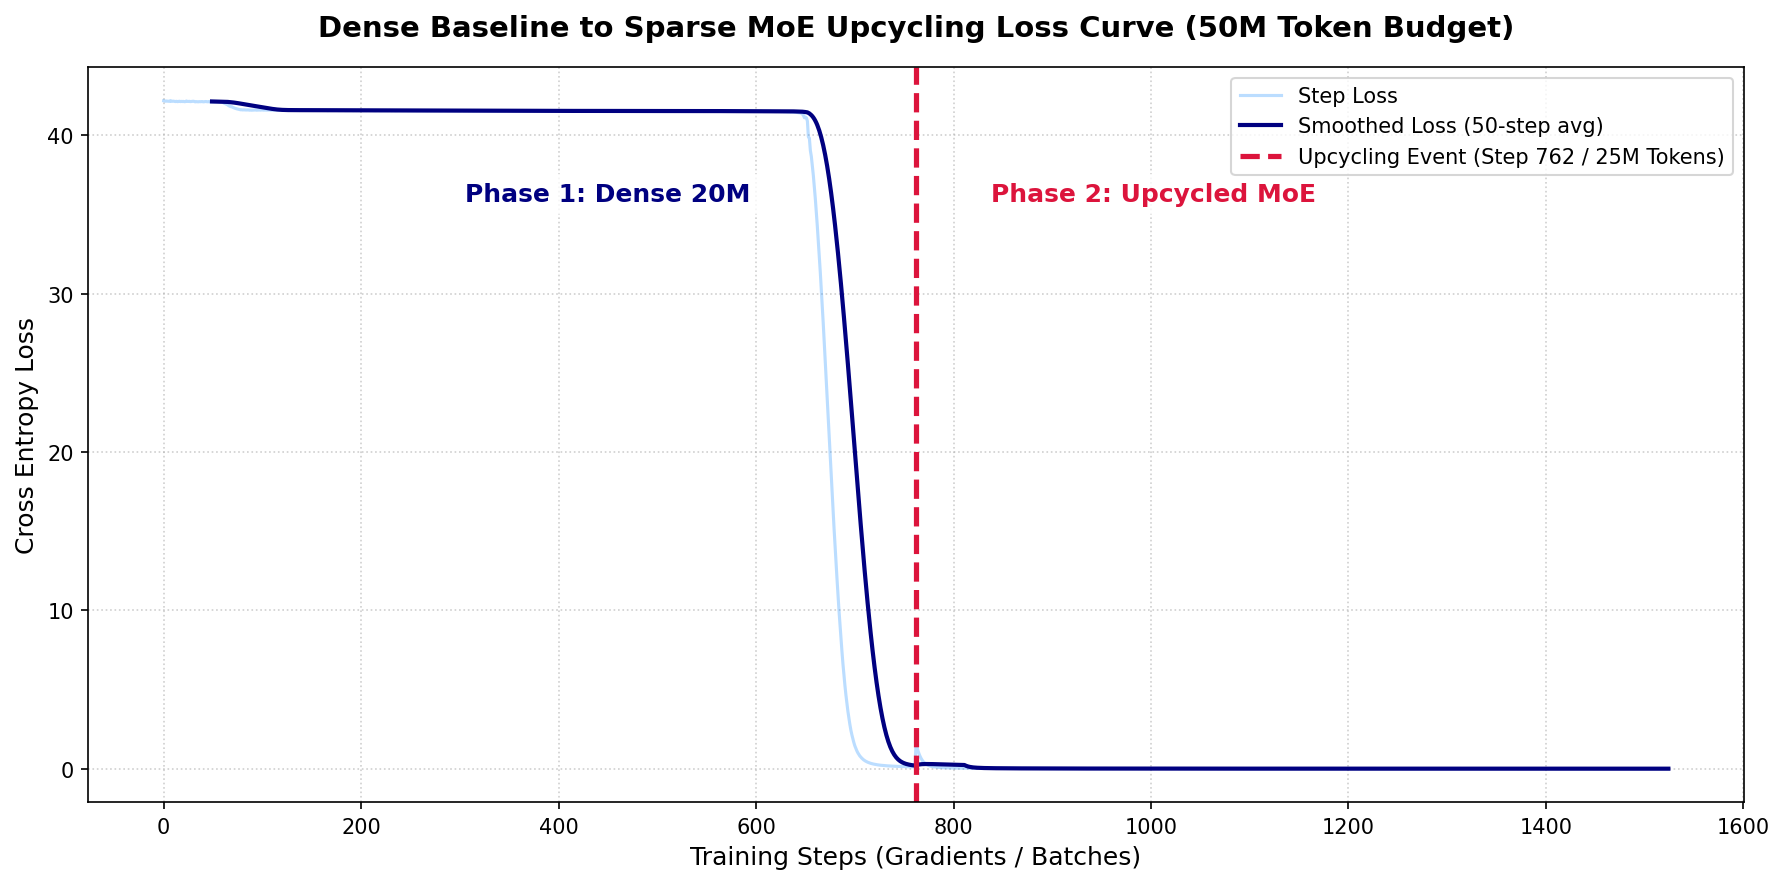


✅ Plot successfully displayed and saved to Drive at:
   /content/drive/MyDrive/MoE_Assignment_Checkpoints/upcycling_loss_plot.png


In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Apply a clean plot style
plt.figure(figsize=(12, 6), dpi=150)

# 1. Plot raw step loss
plt.plot(loss_history, alpha=0.3, color='dodgerblue', label='Step Loss')

# 2. Plot smoothed moving average loss (50-step window)
window_size = 50
if len(loss_history) >= window_size:
    smoothed_loss = np.convolve(loss_history, np.ones(window_size)/window_size, mode='valid')
    plt.plot(range(window_size - 1, len(loss_history)), smoothed_loss,
             color='navy', linewidth=2, label=f'Smoothed Loss ({window_size}-step avg)')

# 3. Add Vertical Marker for the MoE Upcycling Event
plt.axvline(x=UPCYCLE_STEP, color='crimson', linestyle='--', linewidth=2.5,
            label=f'Upcycling Event (Step {UPCYCLE_STEP} / 25M Tokens)')

# 4. Annotate Phase Transitions
plt.text(UPCYCLE_STEP * 0.4, max(loss_history) * 0.85, 'Phase 1: Dense 20M',
         fontsize=12, fontweight='bold', color='navy', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
plt.text(UPCYCLE_STEP * 1.1, max(loss_history) * 0.85, 'Phase 2: Upcycled MoE',
         fontsize=12, fontweight='bold', color='crimson', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formatting Labels and Layout
plt.title("Dense Baseline to Sparse MoE Upcycling Loss Curve (50M Token Budget)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Training Steps (Gradients / Batches)", fontsize=12)
plt.ylabel("Cross Entropy Loss", fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Save image directly to Google Drive
plot_save_path = os.path.join(CHECKPOINT_DIR, 'upcycling_loss_plot.png')
plt.savefig(plot_save_path)
plt.show()

print(f"\n✅ Plot successfully displayed and saved to Drive at:\n   {plot_save_path}")